## DT regressor

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv('BostonHousing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
# features and target
x = df.iloc[:, 0:-1]
y = df.iloc[:, -1]

# data split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [ ]:
# Hyperparameters Tuning
params_grid = {
    'criterion':['squared_error', 'absolute_error', 'poisson'],
    'splitter':['best','random'],
    'max_depth':[None,3,5,7,10],
    'min_samples_split':[2,5,10],
    'max_features':['sqrt','log2'],
    'min_samples_leaf':[1,2,4],
    'max_leaf_nodes':[None,10,20,30,50]
}


grid = GridSearchCV(estimator = DecisionTreeRegressor(random_state=42),param_grid=params_grid, cv = 5, scoring='r2',n_jobs=-1)

In [5]:
grid.fit(x_train, y_train)

# best hyperparameters
print('✅ BEST Hyperparameters:',grid.best_params_)

# best CV score
print('✅ BEST score:',grid.best_score_)

# best model
print('✅ Best estimator:',grid.best_estimator_)

✅ BEST Hyperparameters: {'criterion': 'absolute_error', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'splitter': 'best'}
✅ BEST score: 0.7139012887763917
✅ Best estimator: DecisionTreeRegressor(criterion='absolute_error', max_features='sqrt',
                      min_samples_leaf=2, random_state=42)


### best model training

In [6]:
dt = grid.best_estimator_
dt.fit(x_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_features='sqrt',
                      min_samples_leaf=2, random_state=42)

In [7]:
y_Pred = dt.predict(x_test)
print('R2 score:',r2_score(y_test, y_Pred))

R2 score: 0.6867338734474577


### feature importance

In [8]:
importance_df = pd.DataFrame({
    'Feature':x.columns,
    'Importance':dt.feature_importances_
})

importance_df.sort_values(by = 'Importance',ascending=False)

,Feature,Importance
5,rm,0.442037
9,tax,0.124359
0,crim,0.102926
7,dis,0.087503
6,age,0.072034
12,lstat,0.055773
11,b,0.039931
4,nox,0.030799
10,ptratio,0.025906
8,rad,0.011462


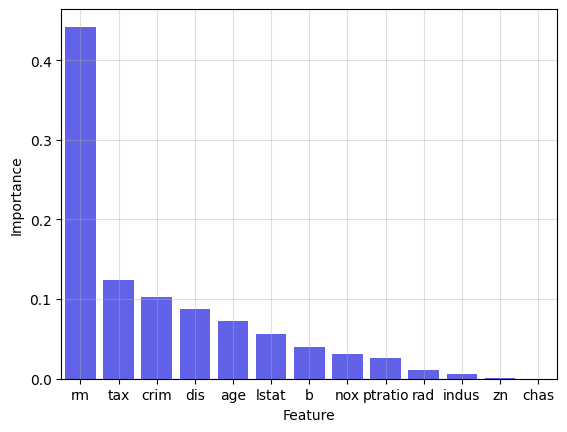

In [9]:
# bar plot
sns.barplot(
    data = importance_df.sort_values(by = 'Importance',ascending=False),
    y = 'Importance',
    x = 'Feature',
    color = 'Blue',
    alpha = 0.7
)
plt.grid(True, alpha = 0.4)
plt.show()

In [14]:
# dimensionlaity reduction
# keeping features whose importance is > 0.02
selected_features = importance_df[importance_df['Importance'] > 0.02]['Feature']
selected_features

0        crim
4         nox
5          rm
6         age
7         dis
9         tax
10    ptratio
11          b
12      lstat
Name: Feature, dtype: object

In [15]:
# train model on reduced data
x_reduced = df[selected_features]
x_reduced.columns

Index(['crim', 'nox', 'rm', 'age', 'dis', 'tax', 'ptratio', 'b', 'lstat'], dtype='object')

In [16]:
# data split
x_trainr, x_testr, y_trainr, y_testr = train_test_split(x_reduced, y, test_size=0.2, random_state=42)

# model train
dt_reduced = DecisionTreeRegressor(random_state=42, **grid.best_params_)
dt_reduced.fit(x_trainr, y_trainr)

DecisionTreeRegressor(criterion='absolute_error', max_features='sqrt',
                      min_samples_leaf=2, random_state=42)

In [17]:
y_PredR = dt_reduced.predict(x_testr)
print('R2 score: ',r2_score(y_test, y_PredR))

R2 score:  0.8214994238003259


> **<span style = 'color:orange'>R2 score has significantly improved after Dimensionality Reduction</span>**

In [19]:
print("\nEnter values for prediction:\n")

user_data = []

for feature in selected_features:
    while True:
        value = input(f"{feature}: ").strip()

        if value == "":
            print("Please enter a numeric value.")
            continue

        try:
            user_data.append(float(value))
            break
        except ValueError:
            print("Invalid input. Enter only numbers.")

user_df = pd.DataFrame([user_data], columns=selected_features)

prediction = dt_reduced.predict(user_df)

print("Predicted House Price:", round(prediction[0], 2))


Enter values for prediction:

Predicted House Price: 37.8
